# Evaluación 4: Segmentación



**Fecha de Creación:** 2 de Julio de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 4 de la asignatura de Inteligencia Artificial 620454. Donde, en base a un contexto de negocio sobre una empresa de comercio electrónico, se desarrollarán múltiples perspectivas de segmentación de clientes (Clustering) mediante el uso de algoritmos de Machine Learning no supervisado, permitiendo el diseño de estrategias de marketing más efectivas.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)
- scikit-learn

Para verificar la versión instalada ejecutar el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
```

# Importación de librerías

In [1]:
!pip install kneed


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from mpl_toolkits.mplot3d import Axes3D
from kneed import KneeLocator

from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs

from IPython.display import HTML

In [3]:
data = pd.read_csv('../data/ingestion/data_clientes.csv')
data.head()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


# Parte 1: Diseño de las segmentaciones

## Enfoque 1: Clientes fieles y su valor

Se busca estudiar el comportamiento de compra de los clientes, ya sea en los volúmenes de compra o en la frecuencia de dichas compras\. El objetivo es encontrar qué clientes significan un mayor valor para la empresa, cuáles son los más leales o aquellos clientes que compran de manera esporádica\.

### Variables seleccionadas y justificación

gasto\_promedio\_mensual: Se incluye porque indica directamente el nivel de inversión mensual del cliente en la plataforma\.  

frecuencia\_compra: Se usa para medir la recurrencia con la que el cliente realiza transacciones en un rango de tiempo\.  

tasa\_recompra: Su inclusión permite medir la lealtad y la proporción de compras que son repetidas\. 

valor\_promedio\_compra: Se requiere para entender el ticket promedio de cada transacción monetaria realizada\. 

antiguedad\_cliente: Se añade porque el tiempo que la persona lleva siendo cliente ayuda a distinguir entre compradores nuevos y clientes con un largo historial con la empresa\. 

### Variables irrelevantes y justificación

visitas\_web\_mensuales y tiempo\_promedio\_sesion: Se excluyen porque miden navegación y no necesariamente significan un valor monetario directo\.

distancia\_envio\_km y gasto\_envio\_promedio: Se excluyen ya que son factores logísticos que no reflejan el comportamiento de compra del cliente\.

### Representación dimensiona de análisis

Al combinar la magnitud del gasto \(gasto\_promedio\_mensual, valor\_promedio\_compra\) con la recurrencia y la retención en el tiempo \(frecuencia\_compra, tasa\_recompra, antiguedad\_cliente\), el modelo logra estructurar con precisión el ciclo de vida económico del cliente\. Esto permite diferenciar entre compradores esporádicos de bajo valor y clientes VIP altamente leales y rentables para el negocio\.

## Enfoque 2: Interacción y participación digital

Este enfoque busca estudiar cómo los clientes interactúan con las plataformas digitales de la empresa\. El propósito es entender si los clientes prefieren canales móviles, su nivel de involucramiento con la app y qué tanto navegan antes de decidir o no una compra\.

### Variables seleccionadas y justificación

visitas\_web\_mensuales: Se incluye por ser la métrica principal para cuantificar el volumen de tráfico que el cliente genera en el sitio web\. 

tiempo\_promedio\_sesion: Es esencial para medir la calidad y profundidad del interés del cliente durante su permanencia en el sitio\.

interacciones\_app: Se selecciona porque demuestra el nivel de uso activo y el engagement directo con la aplicación móvil de la empresa\.

compras\_movil\_pct: Se incluye para identificar la adopción de plataformas móviles frente a canales tradicionales o de escritorio al momento de concretar transacciones\.

dispositivos\_registrados: Ayuda a entender si el cliente utiliza múltiples equipos asociados a su cuenta para interactuar\.  

### Variables irrelevantes y justificación

ingreso\_mensual y gasto\_promedio\_mensual: Se excluyen debido a que el poder adquisitivo y el gasto no explican el modo en que el usuario navega o interactúa con el software\.

edad: Aunque la demografía influye en la tecnología, se excluye para centrar el modelo estrictamente en el comportamiento digital empírico, evitando sesgos generacionales\.

productos\_categoria: Se descarta porque representa preferencias de inventario y no patrones de uso de la interfaz digital\.

### Representación dimensiona de análisis

Este grupo de variables captura el comportamiento y la adopción tecnológica del usuario dentro del ecosistema de la empresa\. Al unificar métricas de volumen de tráfico \(visitas\_web\_mensuales\), profundidad de la navegación \(tiempo\_promedio\_sesion, interacciones\_app\) y preferencias de canal \(compras\_movil\_pct, dispositivos\_registrados\), el enfoque logra aislar los hábitos digitales del poder adquisitivo del cliente\. Así, el conjunto representa con exactitud el nivel de involucramiento y uso de múltiples canales de los usuarios, clave para optimizar la experiencia en la plataforma\.

# Parte 2: Limpieza de datos

En esta sección se realizará una auditoría inicial del estado de los datos con el objetivo de identificar la presencia de valores nulos, registros duplicados, inconsistencias en los tipos de variables o presencia de valores atípicos \(outliers\) que puedan distorsionar los algoritmos basados en distancias \(como K\-Means o Clustering Jerárquico\)\.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                2000 non-null   int64  
 1   ingreso_mensual           2000 non-null   float64
 2   gasto_promedio_mensual    2000 non-null   float64
 3   frecuencia_compra         2000 non-null   float64
 4   valor_promedio_compra     2000 non-null   float64
 5   visitas_web_mensuales     2000 non-null   float64
 6   tiempo_promedio_sesion    2000 non-null   float64
 7   porcentaje_descuentos     2000 non-null   float64
 8   antiguedad_cliente        2000 non-null   float64
 9   productos_categoria       2000 non-null   float64
 10  tasa_recompra             2000 non-null   float64
 11  edad                      2000 non-null   float64
 12  distancia_envio_km        2000 non-null   float64
 13  dispositivos_registrados  2000 non-null   int64  
 14  compras_

Al contar con una columna de identificación \(cliente\_id\), es necesario revisar si los datos se encuentran duplicados\. Lo que, en esta ocasión no lo están\.

## Detección y Manejo de Registros Duplicados

In [5]:
duplicados = data.duplicated().sum()
print(f"Registros duplicados detectados: {duplicados}")

Registros duplicados detectados: 0


In [6]:
def eliminar_duplicados(X : pd.DataFrame):
    """
    Elimina tuplas duplicadas

    Parámetros
    ----------

    X: set de datos

    Retorno
    -------
    Nuevo set de datos sin los duplicados

    """
    return X.drop_duplicates()

## Identificación y Análisis de Valores Nulos \(Faltantes\)

También es necesario revisar posibles valores nulos en las tuplas\. En esta ocasión, no existen nulos\.

In [7]:
# Conteo detallado de valores nulos por columna
valores_nulos = data.isnull().sum()
porcentaje_nulos = (valores_nulos / len(data)) * 100

# Crear dataframe resumen de datos faltantes
resumen_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Valores Nulos', ascending=False)

print("Resumen de valores faltantes por variable:")
display(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

Resumen de valores faltantes por variable:


,Valores Nulos,Porcentaje (%)


## Remover inconsistencias

También se revisan las inconsistencias en el dataset, donde las tasas deben rondar entre 0 y 100 y el resto de columnas deben ser mayores o iguales a 0\.

Al analizar los valores estadísticos de cada columna \(el min y el max\), notamos que no existen valores negativos y que las tasas no superan el 100%, por lo que los datos son consistentes\.

In [8]:
data.describe()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,4751.595336,506.676606,6.751098,74.999679,44.844930,15.534643,40.202617,22.170025,6.803967,61.419886,40.305925,30.359535,2.998500,55.589700,7.995000,24.849528
std,577.494589,2005.699367,490.802040,4.892516,49.858421,32.244533,10.369921,24.393634,13.949826,4.299923,24.088977,11.998714,17.540258,1.435802,25.503595,3.056416,9.841420
min,1.000000,198.780033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.186284,1.000000,10.070770,0.000000,0.000000
25%,500.750000,3167.975454,162.472873,2.454098,37.576579,15.699027,7.553803,19.368307,10.948272,2.931330,42.279331,32.192399,17.588985,2.000000,34.029752,5.984401,18.135908
50%,1000.500000,4237.487383,304.593244,4.696882,56.460878,39.249357,13.009061,34.729085,18.839590,6.571409,62.845532,40.178812,26.923167,3.000000,54.916163,7.950773,24.829411
75%,1500.250000,6093.126173,608.832250,10.940663,104.390959,60.092336,20.148952,60.382058,31.876953,9.653280,83.965427,48.162157,39.706528,4.000000,77.638943,10.109611,31.267205
max,2000.000000,11282.955269,2040.952412,20.690111,233.280357,158.312476,56.262160,108.082995,70.006198,21.530541,104.069512,77.829553,123.404080,5.000000,99.997249,17.477278,59.992447


## Remoción de Identificadores Únicos

La variable cliente\_id actúa únicamente como una clave primaria para identificar a los compradores de la plataforma de comercio electrónico\. Dado que no aporta valor analítico ni variabilidad relevante para la agrupación matemática de los clientes, se procede a su exclusión del conjunto de datos de entrenamiento \(X\)\.

In [9]:
# Separación del dataset eliminando el identificador único
data = data.drop(columns=['cliente_id'])

print(f"Dimensiones de la matriz de características: {data.shape}")
data.head()

Dimensiones de la matriz de características: (2000, 16)


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


## Separación de Características

Se separa el dataset en los conjuntos de datos para cada enfoque\. Donde se descartan las columnas "gasto\_promedio\_mensual" y "tiempo\_promedio\_sesion" al tener alta correlatividad con "valor\_promedio\_compra" y "visitas\_web\_mensuales" respectivamente\.

In [10]:
columnas_comercial = ["frecuencia_compra","tasa_recompra","valor_promedio_compra","antiguedad_cliente"]
data_comercial = data[columnas_comercial]

columnas_digital = ["visitas_web_mensuales","interacciones_app","compras_movil_pct","dispositivos_registrados"]
data_digital = data[columnas_digital]

## Detección de atípicos

Encontrar atípicos en el dataset ayuda a determinar el mejor tipo de escalado para las variables numéricas \(las que conforman el dataset\)\.

Al analizar las gráficas de caja para el enfoque comercial, notamos que "valor\_promedio\_compra" y "antiguedad\_cliente" presentan datos atípicos, siendo mayor este fenómeno en la primera variable\.

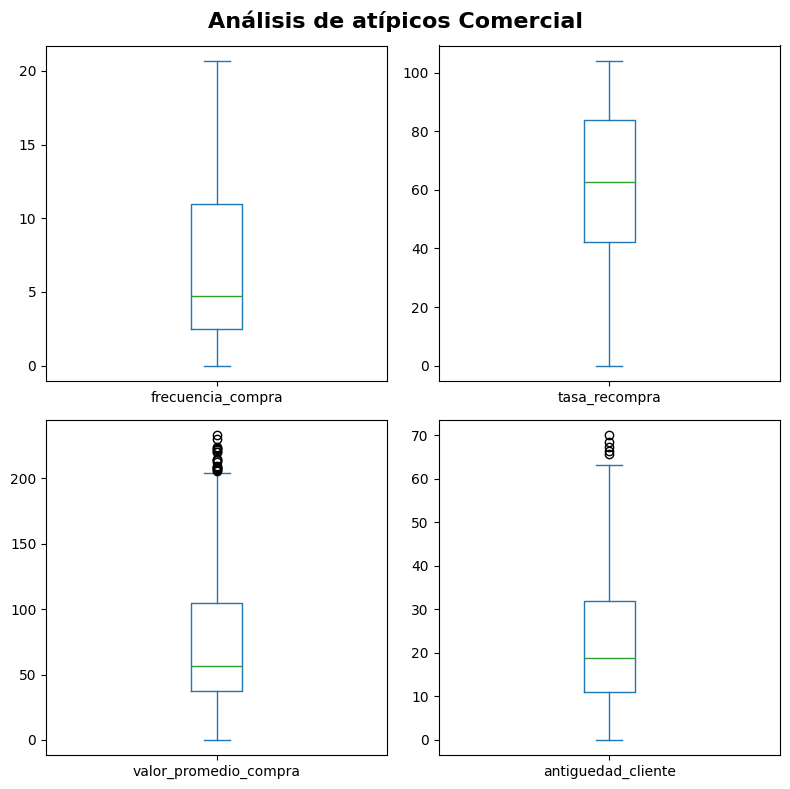

In [11]:
revision_atipicos = columnas_comercial
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()  # convierte la matriz de ejes en un vector

for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box', ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=0)

plt.suptitle("Análisis de atípicos Comercial", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

En el enfoque comercial, notamos que "visitas\_web\_mensuales" e "interacciones\_app" presentan datos atípicos, siendo mayor este fenómeno en la primera variable\.

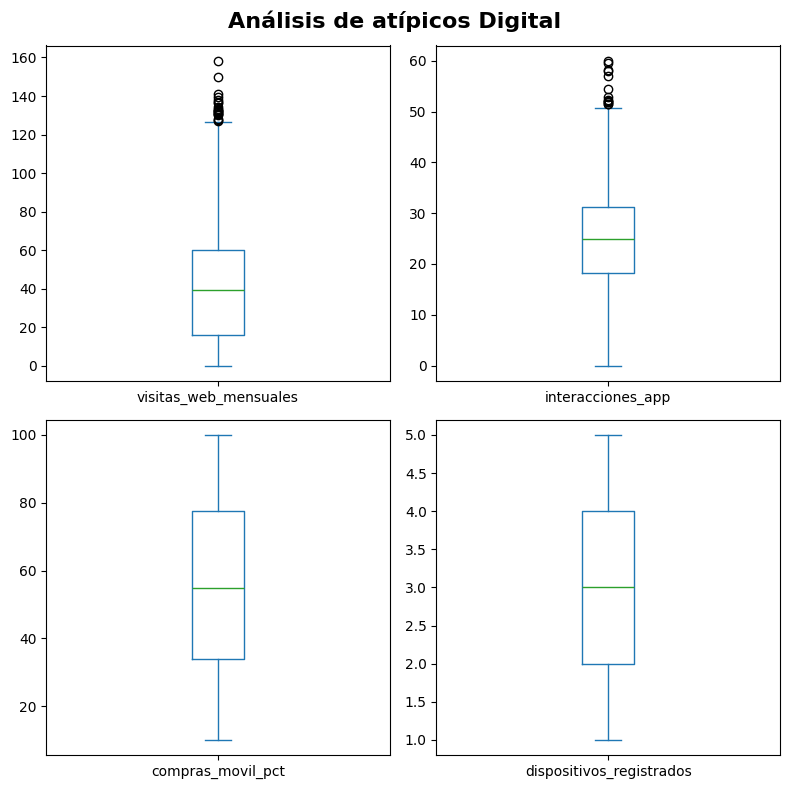

In [12]:
revision_atipicos = columnas_digital
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()  # convierte la matriz de ejes en un vector

for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box', ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=0)

plt.suptitle("Análisis de atípicos Digital", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Implementación del Pipeline de Preprocesamiento Automatizado

Para garantizar un tratamiento consistente y evitar sesgos metodológicos, se define un flujo de preprocesamiento utilizando \`Pipeline\` y \`ColumnTransformer\`\. 

La estrategia metodológica consiste en:

1. Imputación: Completar eventuales valores numéricos faltantes mediante la **mediana** (`SimpleImputer`), protegiendo el proceso de posibles errores.
2. Estandarización: Aplicar un escalado estándar (`StandardScaler`) para transformar las variables numéricas de modo que presenten una media igual a 0 y una desviación estándar de 1. Esto evita que variables con magnitudes muy grandes (como `ingreso_mensual`) dominen de forma artificial el cálculo de distancias sobre variables de escalas pequeñas (como `edad` o `dispositivos_registrados`). Además de manejar mejor los valores atípicos.

In [13]:
# Definición del sub-pipeline robusto para variables numéricas. El dataset solo contiene valores numéricos
pipeline_numerico = Pipeline(steps=[
    ('imputador_mediana', SimpleImputer(strategy='median')),
    ('escalador_estandar', StandardScaler())
])

# Construcción del transformador global de columnas
preprocesador_comercial = ColumnTransformer(
    transformers=[
        ('num_transform', pipeline_numerico, columnas_comercial)
    ],
    remainder='drop'  # Descarta cualquier columna que no haya sido mapeada explícitamente
)
preprocesador_comercial.set_output(transform="pandas")  # Transforma el resultado en un dataframe de pandas

preprocesador_digital = ColumnTransformer(
    transformers=[
        ('num_transform', pipeline_numerico, columnas_digital)
    ],
    remainder='drop'  # Descarta cualquier columna que no haya sido mapeada explícitamente
)
preprocesador_digital.set_output(transform="pandas")  # Transforma el resultado en un dataframe de pandas

# Ajuste y transformación del conjunto de datos limpio
X_comercial = preprocesador_comercial.fit_transform(data)

# Ajuste y transformación del conjunto de datos limpio
X_digital = preprocesador_digital.fit_transform(data)

In [14]:
X_comercial.head()

,num_transform__frecuencia_compra,num_transform__tasa_recompra,num_transform__valor_promedio_compra,num_transform__antiguedad_cliente
0,-1.073152,0.512192,0.170384,-0.756965
1,1.276486,1.107820,1.036992,0.767773
2,-1.148451,-1.391076,-0.811663,-0.780402
3,0.826752,1.099308,-0.439591,1.493683
4,-0.723567,-1.457975,-0.337729,-0.819115


In [15]:
X_digital.head()

,num_transform__visitas_web_mensuales,num_transform__interacciones_app,num_transform__compras_movil_pct,num_transform__dispositivos_registrados
0,1.848108,-1.249987,0.988760,1.394343
1,-0.396847,0.219893,0.064339,-1.392253
2,-1.117398,1.031988,0.360664,-0.695604
3,-0.520513,-0.037523,-0.929143,0.001045
4,-1.159895,1.379578,1.359381,1.394343


## Detección y Manejo de Correlatividad

Al analizar la correlatividad entre variables, notamos que "valor\_promedio\_compra" y "gasto\_promedio\_mensual" se relacionan cerca a lo proporcional, al igual que "tiempo\_promedio\_sesion" y "visitas\_web\_mensuales" \(umbral sobre 0\.8\)\.

Por esto, se considera descartar una de las variables correlacionadas, ya que mantenerlas daría un efecto de "duplicar" una columna\.

In [16]:
umbral = 0.8

corr_matrix = data.corr().abs()
corr_matrix = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pares_altos = corr_matrix.unstack().dropna()
pares_altos = pares_altos[pares_altos >= umbral]
    
df_resultado = pares_altos.reset_index()
df_resultado.columns = ['Variable_1', 'Variable_2', 'Correlacion']
df_resultado = df_resultado.sort_values(by='Correlacion', ascending=False)
    
df_resultado

,Variable_1,Variable_2,Correlacion
0,valor_promedio_compra,gasto_promedio_mensual,0.820289
1,tiempo_promedio_sesion,visitas_web_mensuales,0.806392


# Parte 3: Construcción de modelos

En esta sección se implementará el algoritmo de particionamiento **K-Means** para identificar agrupaciones naturales de clientes en base a sus patrones de consumo y navegación digital. Para evitar la selección arbitraria ("a ojo") del número de clusters ($K$), se automatizará el proceso mediante el criterio matemático del Método del Codo y la librería kneed tal como fue desarrollado en clases.

## Determinación del Número Óptimo de Clústeres "K"

La medida principal para determinar la efectividad de un modelo es la "inercia", que mide la distancia de los datos con respecto a su centroide\. A menor inercia, mejor es el modelo\.

Otra medida que existe es el Silhouette, que determina la calidad de la separación de los datos al medir qué tanto se solapan entre los grupos detectados\. El rendimiento de silhouette se parece a una curva cuadrática convexa: los primeros números de K mejoran su puntuación, pero luego disminuye\.

Como los rendimientos de inercia y Silhouette llegan a contradecirse  a la hora de elegir un número K, se usa el método de selección por "elbow"\. El cual analiza el punto donde la mejora de inercia al aumentar K disminuye, punto el cual también se aproxima al rendimiento máximo de Silhouette\.

In [17]:
from kneed import KneeLocator

def calcularKOptimo(X, nombre):
    # Lista para almacenar los valores de WCSS (Inercia) de cada configuración de K
    wcss = []
    valores_k = range(1, 11)

    # Ejecución iterativa de KMeans para evaluar la dispersión interna
    for k in valores_k:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    # Identificación automática del punto de inflexión (codo) usando KneeLocator
    localizador_codo = KneeLocator(
        valores_k, 
        wcss, 
        curve="convex", 
        direction="decreasing"
    )

    k_optimo = localizador_codo.elbow

    # Visualización del Método del Codo para validación gráfica
    plt.figure(figsize=(9, 5))
    plt.plot(valores_k, wcss, marker='o', linestyle='--', color='#002868', label='Inercia (WCSS)')
    plt.axvline(x=k_optimo, color='red', linestyle=':', linewidth=2, label=f'K Óptimo Sugerido ({k_optimo})')

    plt.title('Método del Codo para Selección de K Óptimo '+nombre, fontsize=12, fontweight='bold')
    plt.xlabel('Número de Clusters (K)', fontsize=10)
    plt.ylabel('Within-Cluster Sum of Squares (Inercia)', fontsize=10)
    plt.xticks(valores_k)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.show()

    return k_optimo


Al buscar el k\-óptimo del enfoque comercial, tenemos que su valor es 3

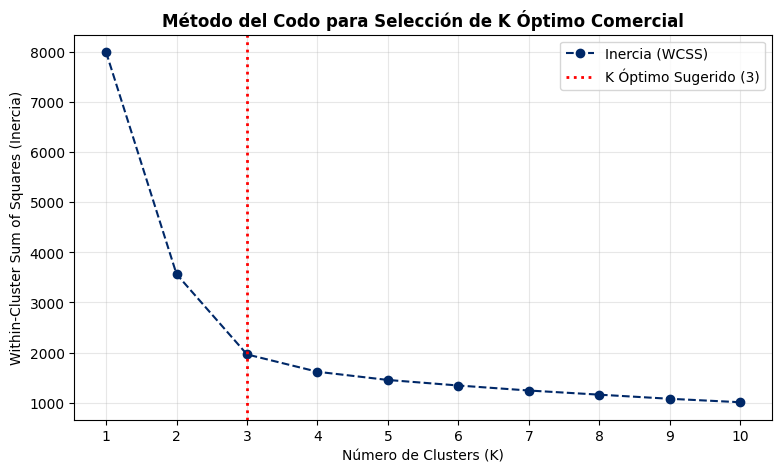

In [18]:
k_optimo_comercial = calcularKOptimo(X_comercial, "Comercial")

Al buscar el k\-óptimo del enfoque digital, tenemos que su valor es 4

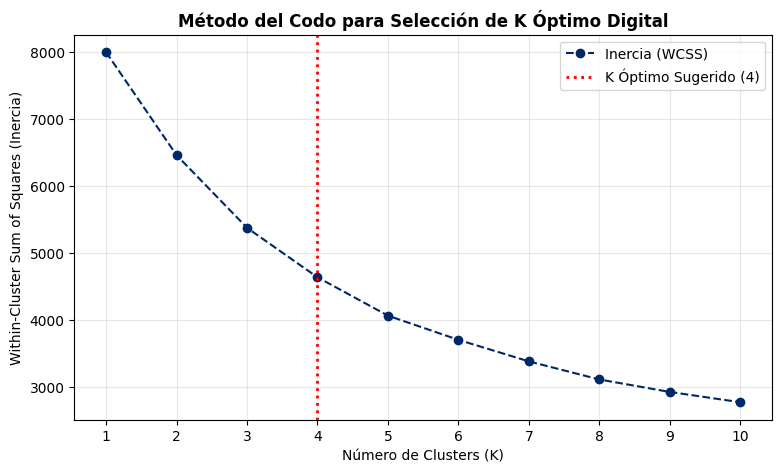

In [19]:
k_optimo_digital = calcularKOptimo(X_digital, "Digital")

## Entrenamiento del Modelo Final y Evaluación de Calidad

Una vez definido el valor de K idóneo, se procede a ajustar el modelo definitivo\. Se evaluará la estructura espacial de los clusters calculando las métricas de validación interna vistas en clase:
Coeficiente de Silhouette: Mide qué tan cercano está cada punto a los puntos de su propio cluster en comparación con los del cluster más cercano \(rango \[\-1, 1\]\)\.

In [20]:
def modelarClusters(X, k_optimo, nombre):
    # Inicialización y ajuste del modelo final con el K óptimo
    modelo_kmeans = KMeans(n_clusters=k_optimo, init='k-means++', n_init=10, random_state=42)
    labels_clusters = modelo_kmeans.fit_predict(X)

    # Incorporación de las etiquetas de segmento
    X_cluster = X.copy()
    X_cluster['cluster'] = labels_clusters

    # Cálculo de métricas intrínsecas de evaluación de clustering
    score_silhouette = silhouette_score(X, labels_clusters)
    score_inertia = modelo_kmeans.inertia_

    print("--- Métricas de Validación del Clustering "+nombre+" ---")
    print(f"Inercia: {score_inertia:.4f}")
    print(f"Coeficiente de Silhouette Global: {score_silhouette:.4f}")

    return {
        'etiquetas': labels_clusters,
        'clusters': modelo_kmeans.cluster_centers_
    }

Al construir los modelos para cada enfoque, notamos que:

- El modelo con enfoque comercial presenta menor inercia \(1962\) y un Silhouette aceptable \(0\.4923 ~ 0\.5\)

- El modelo con enfoque digital presenta mayor inercia \(4636\) y un Silhouette malo \(0\.2031  < 0\.5\)

In [21]:
modelo_comercial = modelarClusters(X_comercial, k_optimo_comercial, "Comercial")
data_comercial_clusters = data_comercial.copy()
data_comercial_clusters['cluster'] =  modelo_comercial["etiquetas"]

modelo_digital = modelarClusters(X_digital, k_optimo_digital, "Digital")
data_digital_clusters = data_digital.copy()
data_digital_clusters['cluster'] = modelo_digital["etiquetas"]

--- Métricas de Validación del Clustering Comercial ---
Inercia: 1961.7672
Coeficiente de Silhouette Global: 0.4923
--- Métricas de Validación del Clustering Digital ---
Inercia: 4636.9167
Coeficiente de Silhouette Global: 0.2031


# Parte 4: Interpretación 

Para interpretar los modelos, definimos una función que determina la desviación estándar de cada variable en un modelo\. De esta manera, se analiza qué variable define más cada centroide\.

In [22]:
def stdModelo(centroides, columnas):
    centroides_std = pd.DataFrame(
        centroides,
        columns=columnas
    )

    return centroides_std.std()

## Enfoque comercial

### Definición variable más importante

Al analizar la desviación estándar de cada columna, notamos que "valor\_promedio\_compra" es el que más representa al enfoque comercial con un valor de 1\.24

In [23]:
stdModelo(modelo_comercial["clusters"],columnas_comercial)

frecuencia_compra        1.031201
tasa_recompra            1.006198
valor_promedio_compra    1.237822
antiguedad_cliente       1.028208
dtype: float64

### Características de los clusters

Analizando los promedios de cada columna por clúster vemos que:

- Cluster 0: en promedio, los clientes de este clúster compran 2 veces cada mes, repiten un 42% de los productos, el valor de compra promedio es de 57 y llevan cerca de 12 años comprando en la tienda

- Cluster 1: en promedio, los clientes de este clúster compran 12 veces cada mes, repiten un 90% de los productos, el valor de compra promedio es de 152 y llevan más de 40 años comprando en la tienda

- Cluster 2: en promedio, los clientes de este clúster compran 10 veces cada mes, repiten un 71% de los productos, el valor de compra promedio es de 36 y llevan cerca de 25 años comprando en la tienda

In [24]:
data_comercial_clusters.groupby("cluster").mean().round(2)

,frecuencia_compra,tasa_recompra,valor_promedio_compra,antiguedad_cliente
cluster,,,,
0,2.49,42.18,56.66,11.61
1,12.09,90.29,152.03,40.28
2,9.95,71.28,36.53,25.40


### Descripción de los clusters

Cluster 0 \(Clientes esporádicos\): Estos no presentan el menor valor promedio por compra, lo que puede significar un posible aumento de interés en el comercio\. El negocio podría enfocar su marketing en los clientes esporádicos para fidelizarlos en la tienda\.
Cluster 1 \(Clientes fieles\): Son aquellos que llevan la mayor cantidad de tiempo acudiendo al comercio y gastan sustancialmente más que el resto\. Además de tener la mayor tasa de recompra\.  El negocio podría enfocar su marketing en los clientes fieles para darles incentivos por su lealtad y para que estos sugieran la tienda a sus conocidos\.
Cluster 2 \(Clientes concurrentes\): Son clientes medianamente familiarizados con la empresa, pero que realizan compras más pequeñas\. Su frecuencia de compra es alta, pero no necesariamente significa un beneficio monetario significativo para la empresa\. El negocio podría enfocar su marketing en los clientes concurrentes para motivarlos a comprar más\.

## Enfoque digital

### Definición variable más importante

Al analizar la desviación estándar de cada columna, notamos que "visitas\_web\_mensuales " es el que más representa al enfoque digital con un valor de 1\.03

In [25]:
stdModelo(modelo_digital["clusters"],columnas_digital)

visitas_web_mensuales       1.035906
interacciones_app           0.229520
compras_movil_pct           0.812841
dispositivos_registrados    0.745899
dtype: float64

### Características de los clusters

Analizando los promedios de cada columna por clúster vemos que:

- Cluster 0: en promedio, los clientes de este clúster visitan la página web 31 veces \(más que diariamente\), interactúan 22 veces en cada sesión, un 38% de sus compras las realizan por teléfono y utilizan 4 dispositivos para acceder a su cuenta\.

- Cluster 1: en promedio, los clientes de este clúster visitan la página web 99 veces \(más de 3 veces al día\), interactúan 24 veces en cada sesión, un 55% de sus compras las realizan por teléfono y utilizan 3 dispositivos para acceder a su cuenta\.

- Cluster 2: en promedio, los clientes de este clúster visitan la página web 31 veces \(más que diariamente\), interactúan 28 veces en cada sesión, un 40% de sus compras las realizan por teléfono y utilizan 2 dispositivos para acceder a su cuenta\.

- Cluster 3: en promedio, los clientes de este clúster visitan la página web 33 veces \(más que diariamente\), interactúan 25 veces en cada sesión, un 83% de sus compras las realizan por teléfono y utilizan 3 dispositivos para acceder a su cuenta\.

In [26]:
data_digital_clusters.groupby("cluster").mean().round(2)

,visitas_web_mensuales,interacciones_app,compras_movil_pct,dispositivos_registrados
cluster,,,,
0,31.31,22.46,37.66,4.32
1,99.00,24.29,55.74,2.85
2,31.94,27.89,40.44,1.70
3,33.44,24.73,82.89,3.03


### Descripción de clusters

Cluster 0 \(Usuarios multidispositivo\): Son los clientes que no destacan por su actividad móvil, ya sea en compras o interacciones, pero poseen la mayor cantidad de dispositivos registrados\. Al ver que poseen una baja cantidad de compras móviles, da a entender que si bien interactúan con el comercio desde diferentes dispositivos, suelen concretar la compra desde el navegador \(PC\) porque les puede resultar más cómodo\. La empresa podría hallar una forma de mejorar la experiencia móvil al momento de realizar una compra para que este tipo de clientes no se apeguen a un solo dispositivo\.
Cluster 1 \(Usuarios de web intensos\): Destacan por su alta cantidad de visitas web mensuales\. Se puede decir que pasan mucho tiempo investigando y comparando precios antes de realizar la compra\. No posee una cantidad de dispositivos registrados ni interacciones con la app sobresalientes\. La empresa debería mejorar la experiencia de navegación web, ya que quizás el alto tiempo invertido en el navegador puede resultar frustrante para este tipo de clientes\.
Cluster 2 \(Frecuentes de app\): Estos clientes son el punto medio del comercio\. Son los que poseen la mayor cantidad de interacciones con la app y la menor cantidad de dispositivos registrados, por lo que se puede decir que son aquellos que pasan la mayor parte del tiempo en su dispositivo más familiarizado, el celular\. La empresa podría ofrecer recompensas por el uso intensivo de la aplicación móvil de la tienda para incentivar a estos compradores a seguir acudiendo a la app\.
Cluster 3 \(Compradores mobile\-first\): Dominan las compras a través del teléfono móvil, alcanzando un 82,89%\. Sus visitas web son en promedio 33,44, lo que indica que no pierden tiempo navegando en la web tradicional; van directo a su dispositivo móvil para realizar transacciones rápidas y directas\. Al igual que con el clúster 0, la empresa podría encuestar a este tipo de clientes para hallar la razón de su alto apego a la app y poder aumentar las ventas también en la página web\.

## Comparación de resultados

En conclusión, ambos enfoques han sido útiles para hallar patrones de compra y comportamiento en los clientes del comercio electrónico\. Cada cliente ahora pertenece a 2 clústeres distintos en donde es clasificado, tanto en valor y fidelidad con la empresa como en su comportamiento y participación con el comercio\. Este tipo de información sobre la clientela resulta crucial e increíblemente ventajoso para la empresa, pudiendo tomar decisiones sobre cada conjunto de clientes dentro de un clúster, para así poder aumentar sus ventas y reconocimiento\.

# Reflexión y conclusiones

### ¿Por qué dos modelos de segmentación construidos sobre conjuntos de variables diferentes pueden producir agrupaciones distintas para un mismo cliente? ¿Qué ventajas tiene analizar a los clientes desde múltiples perspectivas en lugar de utilizar un único modelo?

El propósito de separar el conjunto de variables para entrenar dos modelos distintos es crear múltiples clasificaciones para un mismo cliente, donde estas clasificaciones puedan abarcar ámbitos comerciales, digitales, entre otros, sin depender el uno del otro\. Los beneficios de tener más de un modelo son que se analizan solo las variables específicas de ese enfoque sin tener en cuenta las demás, lo que resulta ventajoso ya que un cliente puede presentar un comportamiento símbolo de alto poder adquisitivo, pero dicho comportamiento puede no ser relevante ni impactante al momento de analizar su actividad como usuario digital\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6677395f-918b-4204-b94c-c20869748c17' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>